# OSM roads with real noise values (dB) — Lyon

Regression counterpart of `LYO_OSM_roads_noise_class.ipynb`, mirroring Barcelona's `OSM_roads_noise_regre.ipynb`.

The raw dB values were already computed by the class pipeline (same segments, same noise assignment) and stored in `../layers/LYO_noise_streets.gpkg`; here they simply replace the 0–4 noise classes, so all road features stay **identical** to the classification dataset.

Lyon's strategic noise map provides Lden (24h composite) and Ln (night) rasters: db_day and db_evening are both the Lden value sampled at the street midpoint, db_night is Ln, as in the class pipeline.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import matplotlib.pyplot as plt

## Load the class-pipeline road features and the noise streets layer

In [2]:
roads_class = pd.read_csv("data/osm_roads_noise_class.csv")
noise_streets = gpd.read_file("../layers/LYO_noise_streets.gpkg")

print("Class CSV:", roads_class.shape)
print("Noise streets:", noise_streets.shape)
roads_class.head()

Class CSV: (7159, 11)
Noise streets: (7159, 11)


C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,143403_21714981_0,4,4,3,5,4001.051496,0.0,366.150625,98.073488,0.0,213.549543
1,143403_21718288_0,4,4,3,5,4005.447822,0.0,373.342535,98.501227,0.0,215.068457
2,143403_143408_0,4,4,3,2,3902.900937,0.0,323.583327,98.501227,0.0,215.068457
3,143408_21718264_0,3,3,1,5,3812.886444,0.0,323.583327,0.000000,0.0,293.111426
4,143408_932576340_0,4,4,3,2,3809.626885,0.0,274.800044,108.501123,0.0,293.111426


## Replace the noise classes with the raw dB values

In [3]:
db = noise_streets[['segment_id']].copy()
db['noise_day'] = noise_streets['db_day'].astype(float)
db['noise_evening'] = noise_streets['db_evening'].astype(float)
db['noise_night'] = noise_streets['db_night'].astype(float)
db['segment_id'] = db['segment_id'].astype(str)

roads_regre = roads_class.drop(columns=['noise_day', 'noise_evening', 'noise_night']).copy()
roads_regre['road_id'] = roads_regre['road_id'].astype(str)
roads_regre = roads_regre.merge(db, left_on='road_id', right_on='segment_id', how='left')
roads_regre = roads_regre.drop(columns=['segment_id'])

# restore the Barcelona column order: noise columns right after road_id
noise_cols = ['noise_day', 'noise_evening', 'noise_night']
ordered = ['road_id'] + noise_cols + [c for c in roads_regre.columns if c != 'road_id' and c not in noise_cols]
roads_regre = roads_regre[ordered]

print(f"Rows: {len(roads_regre)} (class CSV: {len(roads_class)})")
roads_regre[noise_cols].describe()

Rows: 7159 (class CSV: 7159)


,noise_day,noise_evening,noise_night
count,7159.000000,7159.000000,7159.000000
mean,64.862778,64.862778,54.512495
std,6.336150,6.336150,6.309953
min,41.396999,41.396999,31.284000
25%,60.005001,60.005001,49.665001
50%,63.555000,63.555000,53.214001
75%,70.418499,70.418499,60.032001
max,86.014000,86.014000,75.635002


## Sanity checks

In [4]:
assert len(roads_regre) == len(roads_class), "row count changed by the merge"
assert roads_regre[noise_cols].isna().sum().sum() == 0, "NaN noise values after merge"
print("dB ranges:")
print(roads_regre[noise_cols].agg(['min', 'max']))
print("All sanity checks passed.")

dB ranges:
     noise_day  noise_evening  noise_night
min  41.396999      41.396999    31.284000
max  86.014000      86.014000    75.635002
All sanity checks passed.


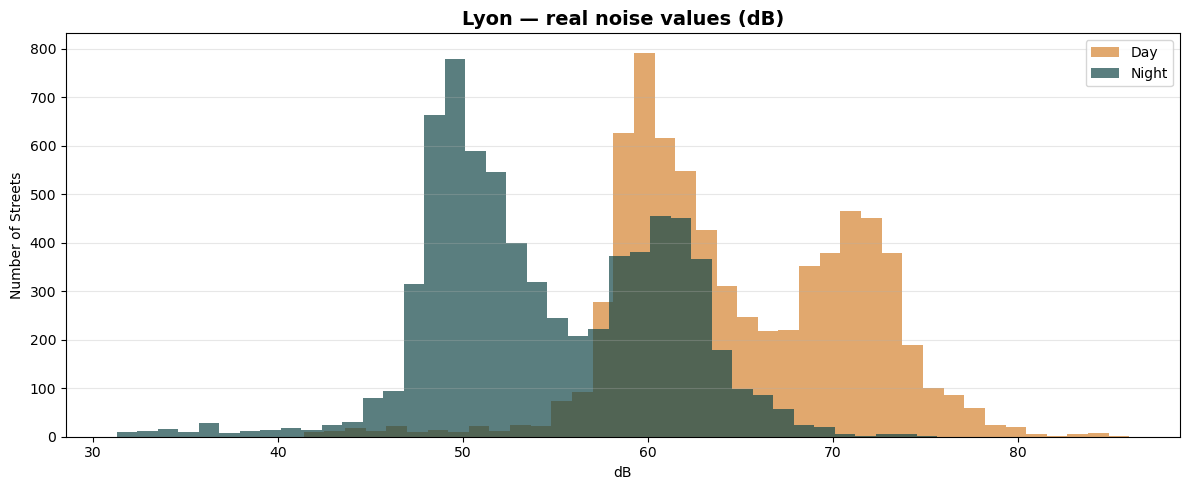

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(roads_regre['noise_day'], bins=40, color='#d58430', alpha=0.7, label='Day')
ax.hist(roads_regre['noise_night'], bins=40, color='#144849', alpha=0.7, label='Night')
ax.set_title('Lyon — real noise values (dB)', fontsize=14, fontweight='bold')
ax.set_xlabel('dB')
ax.set_ylabel('Number of Streets')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Export to CSV

In [6]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
roads_regre.to_csv(os.path.join(output_dir, "osm_roads_noise_regre.csv"), index=False)
print("Exported osm_roads_noise_regre.csv")

Exported osm_roads_noise_regre.csv
